 Analyzing dataset distribution...


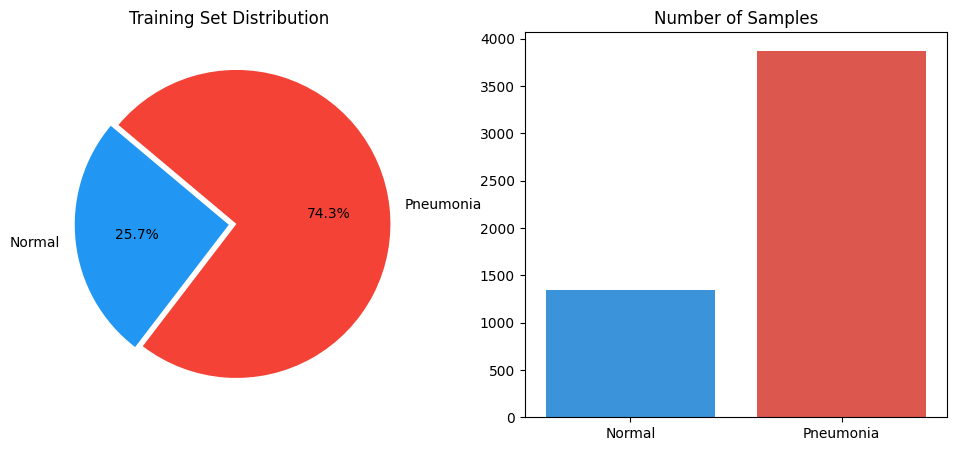

Previewing Normal cases...


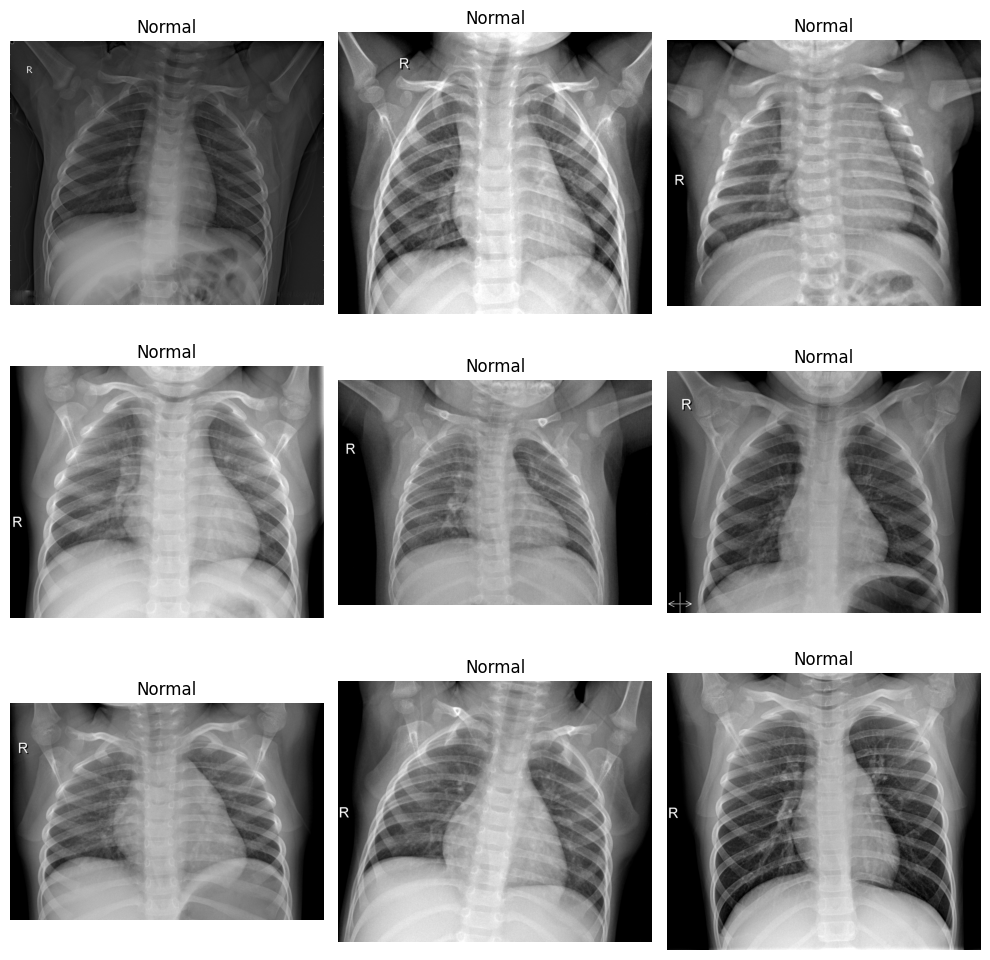

Previewing Pneumonia cases...


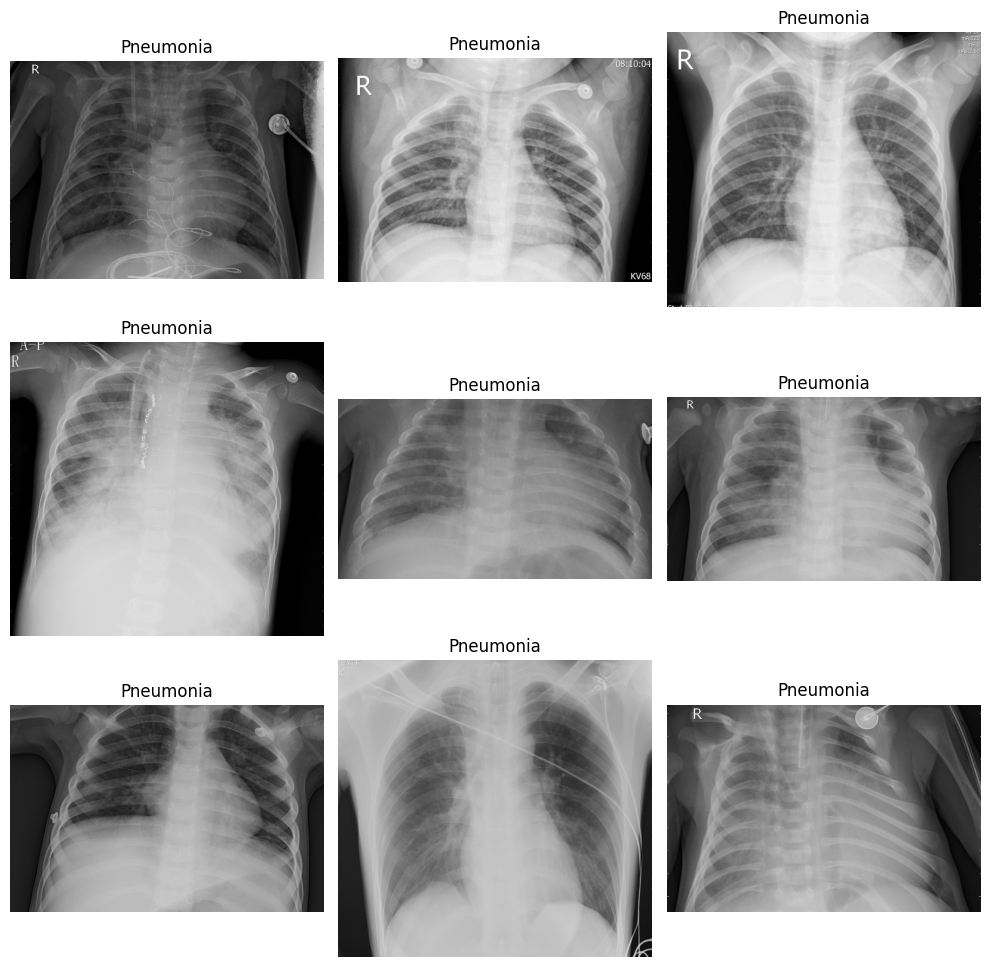

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

 Setup Complete!
 Final Class Weights for Imbalance: {0: np.float64(1.9445479962721341), 1: np.float64(0.6730645161290323)}


In [4]:
# 1. SETTINGS & ADVANCED EDA (SILENT MODE)
import os
import warnings
import logging

# --- 1a. System Log Suppression (Must be done before importing TF) ---
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['AUTOGRAPH_VERBOSITY'] = '0'

# Suppress Python & Seaborn warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
# Suppress TensorFlow python-level logs
tf.get_logger().setLevel('ERROR')
logging.getLogger('tensorflow').setLevel(logging.ERROR)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dataset Paths
train_dir = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train'
test_dir = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test'

print(" Analyzing dataset distribution...")

# --- 1b. Target Distribution Visualization ---
train_counts = {
    'Normal': len(os.listdir(os.path.join(train_dir, 'NORMAL'))),
    'Pneumonia': len(os.listdir(os.path.join(train_dir, 'PNEUMONIA')))
}

plt.figure(figsize=(12, 5))

# Pie Chart
plt.subplot(1, 2, 1)
plt.pie(train_counts.values(), labels=train_counts.keys(), autopct='%1.1f%%', 
        colors=['#2196F3', '#F44336'], startangle=140, explode=[0, 0.05])
plt.title('Training Set Distribution')

# Bar Chart
plt.subplot(1, 2, 2)
sns.barplot(
    x=list(train_counts.keys()), 
    y=list(train_counts.values()), 
    hue=list(train_counts.keys()), 
    palette=['#2196F3', '#F44336'], 
    legend=False
)
plt.title('Number of Samples')
plt.show()

# --- 1c. Sample Image Preview Grid ---
def plot_sample_grid(directory, label, title):
    folder = os.path.join(directory, label)
    files = os.listdir(folder)[:9]
    plt.figure(figsize=(10, 10))
    for i, file in enumerate(files):
        img = plt.imread(os.path.join(folder, file))
        plt.subplot(3, 3, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"{title}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("Previewing Normal cases...")
plot_sample_grid(train_dir, 'NORMAL', 'Normal')
print("Previewing Pneumonia cases...")
plot_sample_grid(train_dir, 'PNEUMONIA', 'Pneumonia')

# --- 1d. Data Generators (Removed 'verbose=0' to fix TypeError) ---
train_datagen = ImageDataGenerator(rescale=1./255, zoom_range=0.2, rotation_range=15, horizontal_flip=True, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(train_dir, target_size=(224, 224), batch_size=32, class_mode='binary', subset='training')
val_data = train_datagen.flow_from_directory(train_dir, target_size=(224, 224), batch_size=32, class_mode='binary', subset='validation')
test_data = test_datagen.flow_from_directory(test_dir, target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False)

# Class Weights
labels = train_data.classes
weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
class_weight_dict = dict(enumerate(weights))

print(f"\n Setup Complete!")
print(f" Final Class Weights for Imbalance: {class_weight_dict}")

In [5]:
# 2. TWO-PHASE MODEL TRAINING (TRANSFER LEARNING + FINE-TUNING)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# --- Phase 1: Feature Extraction ---
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False 

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x) 
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print(" Starting Phase 1: Training the Dense Layers...")
h1 = model.fit(train_data, epochs=10, validation_data=val_data, class_weight=class_weight_dict, callbacks=[early_stop])

# --- Phase 2: Fine-Tuning ---
print("\n Starting Phase 2: Fine-Tuning the last 20 layers...")
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=0.00001), loss='binary_crossentropy', metrics=['accuracy'])
h2 = model.fit(train_data, epochs=10, validation_data=val_data, class_weight=class_weight_dict, callbacks=[early_stop])

# Saving the final model
model.save('pneumonia_model_final.h5')
print("\n Training complete and model saved successfully!")

 Starting Phase 1: Training the Dense Layers...
Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 121s 856ms/step - accuracy: 0.7239 - loss: 0.5094 - val_accuracy: 0.8821 - val_loss: 0.2733
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 99s 753ms/step - accuracy: 0.8954 - loss: 0.2360 - val_accuracy: 0.8984 - val_loss: 0.2454
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 98s 746ms/step - accuracy: 0.9032 - loss: 0.2055 - val_accuracy: 0.9175 - val_loss: 0.2022
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 98s 747ms/step - accuracy: 0.9239 - loss: 0.1824 - val_accuracy: 0.8936 - val_loss: 0.2313
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 97s 739ms/step - accuracy: 0.9354 - loss: 0.1616 - val_accuracy: 0.9156 - val_loss: 0.1823
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 98s 746ms/step - accuracy: 0.9302 - loss: 0.1588 - val_accuracy: 0.8897 - val_loss: 0.2588
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 98s 745ms/step - accuracy: 0.9281 - loss: 0.1786 - val_accuracy: 0.9329 - val_loss: 0.1667
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━


 Training complete and model saved successfully!


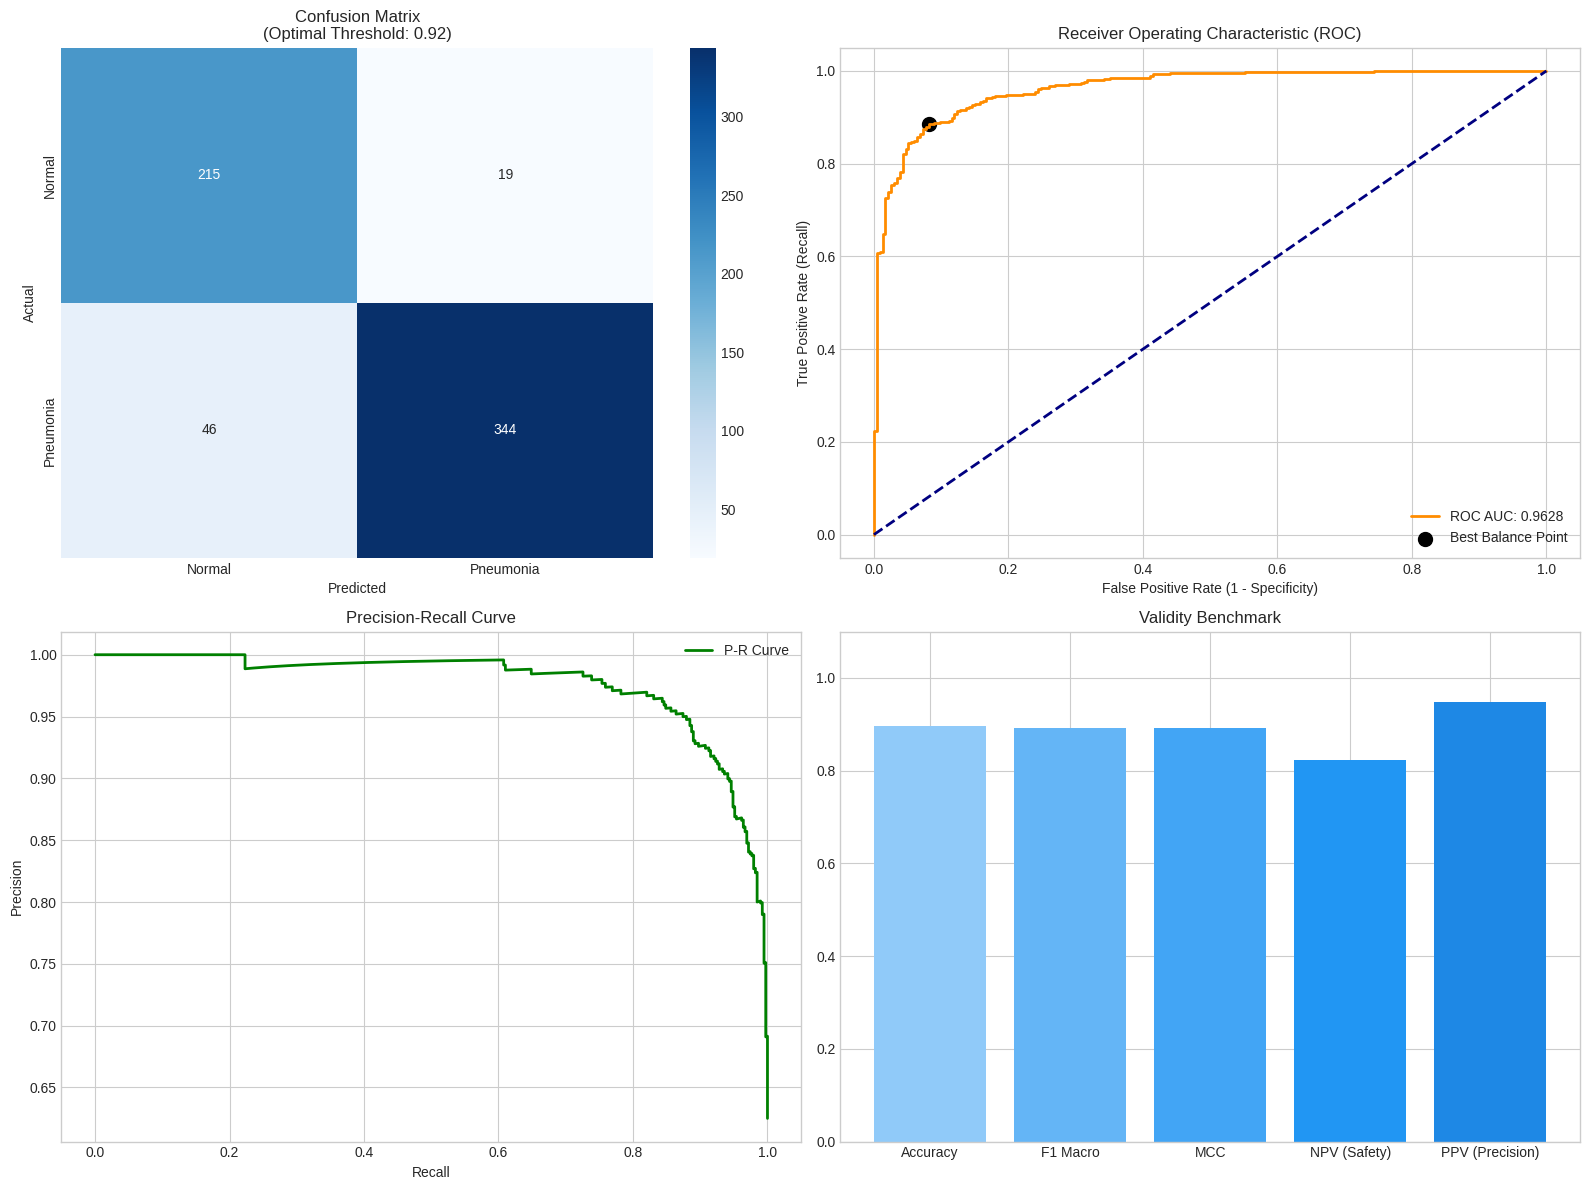


             ADVANCED MEDICAL PERFORMANCE REPORT
TEST ACCURACY:       89.58%
ROC AUC SCORE:       0.9628
MCC SCORE:           0.7860  <-- Reliable overall performance
BRIER SCORE:         0.0930  <-- Confidence/Calibration (Lower is better)
------------------------------------------------------------
SENSITIVITY (Recall): 88.46%  (Ability to detect Pneumonia)
SPECIFICITY:         91.88%  (Ability to detect Normal)
------------------------------------------------------------
NPV (Safety):        82.38%  (Confidence when AI says 'Healthy')
PPV (Precision):     94.77%  (Confidence when AI says 'Pneumonia')

Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       0.82      0.92      0.87       234
   Pneumonia       0.95      0.88      0.91       390

    accuracy                           0.90       624
   macro avg       0.89      0.90      0.89       624
weighted avg       0.90      0.90      0.90       624



In [8]:
# 3. COMPREHENSIVE PERFORMANCE DASHBOARD & VALID METRICS
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, f1_score, matthews_corrcoef, brier_score_loss
import pandas as pd
import numpy as np

# 1. Get Predictions
test_data.reset()
y_pred_probs = model.predict(test_data, verbose=0).ravel()
y_true = test_data.classes

# 2. Threshold Optimization (G-Mean method for Balancing Sensitivity/Specificity)
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
gmeans = np.sqrt(tpr * (1-fpr))
ix = np.argmax(gmeans)
best_thresh = thresholds[ix]
y_pred = (y_pred_probs > best_thresh).astype(int)

# 3. Calculate Advanced Medical Metrics
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
mcc = matthews_corrcoef(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average='macro')
roc_auc = auc(fpr, tpr)
brier = brier_score_loss(y_true, y_pred_probs)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0 # Negative Predictive Value
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0 # Positive Predictive Value

# 4. Visualization Setup
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

# --- Subplot A: Confusion Matrix ---
sns.heatmap([[tn, fp], [fn, tp]], annot=True, fmt='d', cmap='Blues', ax=ax[0,0],
            xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
ax[0,0].set_title(f'Confusion Matrix\n(Optimal Threshold: {best_thresh:.2f})')
ax[0,0].set_xlabel('Predicted')
ax[0,0].set_ylabel('Actual')

# --- Subplot B: ROC Curve ---
ax[0,1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC AUC: {roc_auc:.4f}')
ax[0,1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[0,1].scatter(fpr[ix], tpr[ix], marker='o', color='black', s=100, label='Best Balance Point')
ax[0,1].set_title('Receiver Operating Characteristic (ROC)')
ax[0,1].set_xlabel('False Positive Rate (1 - Specificity)')
ax[0,1].set_ylabel('True Positive Rate (Recall)')
ax[0,1].legend()

# --- Subplot C: Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_true, y_pred_probs)
ax[1,0].plot(recall, precision, color='green', lw=2, label='P-R Curve')
ax[1,0].set_title('Precision-Recall Curve')
ax[1,0].set_xlabel('Recall')
ax[1,0].set_ylabel('Precision')
ax[1,0].legend()

# --- Subplot D: Validity Metrics Comparison ---
validity_metrics = {
    'Accuracy': (y_pred == y_true).mean(),
    'F1 Macro': f1_macro,
    'MCC': (mcc + 1) / 2, # Normalized to 0-1 for visualization
    'NPV (Safety)': npv,
    'PPV (Precision)': ppv
}
ax[1,1].bar(validity_metrics.keys(), validity_metrics.values(), color=['#90caf9', '#64b5f6', '#42a5f5', '#2196f3', '#1e88e5'])
ax[1,1].set_title('Validity Benchmark')
ax[1,1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

# 5. Final Professional Medical Report
print("\n" + "="*60)
print("             ADVANCED MEDICAL PERFORMANCE REPORT")
print("="*60)
print(f"TEST ACCURACY:       {(y_pred == y_true).mean()*100:.2f}%")
print(f"ROC AUC SCORE:       {roc_auc:.4f}")
print(f"MCC SCORE:           {mcc:.4f}  <-- Reliable overall performance")
print(f"BRIER SCORE:         {brier:.4f}  <-- Confidence/Calibration (Lower is better)")
print(f"F1-SCORE (MACRO):    {f1_macro:.4f}  <-- Balanced class assessment")
print("-" * 60)
print(f"SENSITIVITY (Recall): {tpr[ix]*100:.2f}%  (Ability to detect Pneumonia)")
print(f"SPECIFICITY:         {(1-fpr[ix])*100:.2f}%  (Ability to detect Normal)")
print("-" * 60)
print(f"NPV (Safety):        {npv*100:.2f}%  (Confidence when AI says 'Healthy')")
print(f"PPV (Precision):     {ppv*100:.2f}%  (Confidence when AI says 'Pneumonia')")
print("="*60)
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

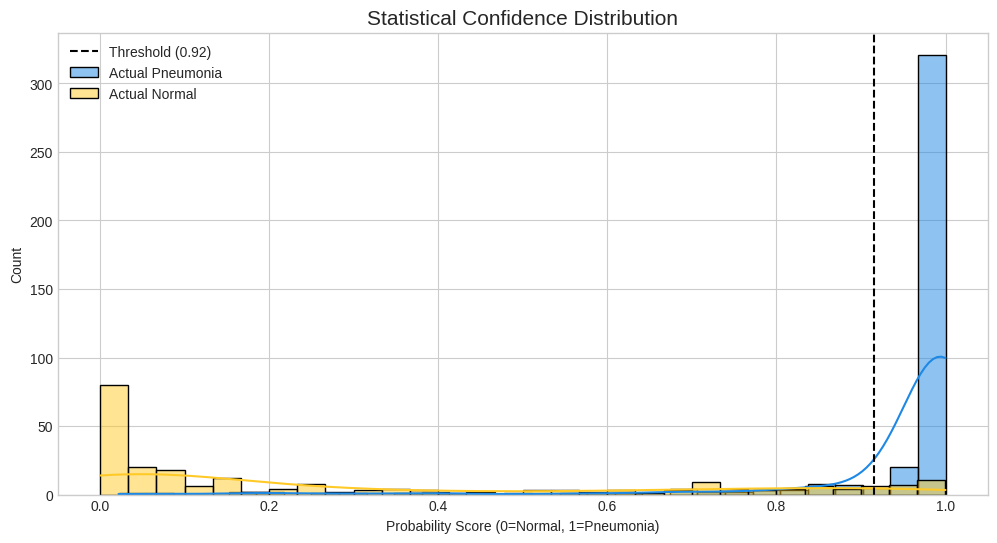


     FINAL CLINICAL SUMMARY TABLE


,Metric,Value,Interpretation
0,Accuracy,89.58%,Overall correctness
1,ROC AUC,0.9628,Discrimination power
2,MCC Score,0.7860,Correlation (Imbalance-robust)
3,F1 Macro,0.8912,Balanced class average
4,Sensitivity,88.46%,Pneumonia detection rate
5,Specificity,91.88%,Healthy detection rate
6,NPV,82.38%,Reliability of 'Normal' label
7,PPV,94.77%,Reliability of 'Pneumonia' label
8,Brier Score,0.0930,Prediction calibration


In [18]:
# 4. CLINICAL PROBABILITY ANALYSIS & SUMMARY TABLE 
import pandas as pd
import seaborn as sns

# 1. Statistics: Prediction Probability Distribution
plt.figure(figsize=(12, 6))
# Κατανομή πιθανοτήτων για τις δύο κλάσεις
sns.histplot(y_pred_probs[y_true == 1], color='#1e88e5', label='Actual Pneumonia', kde=True, bins=30, alpha=0.5)
sns.histplot(y_pred_probs[y_true == 0], color='#ffca28', label='Actual Normal', kde=True, bins=30, alpha=0.5)

plt.axvline(best_thresh, color='black', linestyle='--', label=f'Threshold ({best_thresh:.2f})')
plt.title('Statistical Confidence Distribution', fontsize=15)
plt.xlabel('Probability Score (0=Normal, 1=Pneumonia)')
plt.ylabel('Count')
plt.legend()
plt.show()

# 2. General Results Summary Table (Pandas DataFrame)
# Οργάνωση των αποτελεσμάτων σε πίνακα για επαγγελματική παρουσίαση
results_data = {
    "Metric": ["Accuracy", "ROC AUC", "MCC Score", "F1 Macro", "Sensitivity", "Specificity", "NPV", "PPV", "Brier Score"],
    "Value": [
        f"{(y_pred == y_true).mean()*100:.2f}%",
        f"{roc_auc:.4f}",
        f"{mcc:.4f}",
        f"{f1_macro:.4f}",
        f"{tpr[ix]*100:.2f}%",
        f"{(1-fpr[ix])*100:.2f}%",
        f"{npv*100:.2f}%",
        f"{ppv*100:.2f}%",
        f"{brier:.4f}"
    ],
    "Interpretation": [
        "Overall correctness",
        "Discrimination power",
        "Correlation (Imbalance-robust)",
        "Balanced class average",
        "Pneumonia detection rate",
        "Healthy detection rate",
        "Reliability of 'Normal' label",
        "Reliability of 'Pneumonia' label",
        "Prediction calibration"
    ]
}

df_results = pd.DataFrame(results_data)
print("\n" + "="*40)
print("     FINAL CLINICAL SUMMARY TABLE")
print("="*40)
display(df_results) # Εμφάνιση ως ωραίος πίνακας στο Kaggle

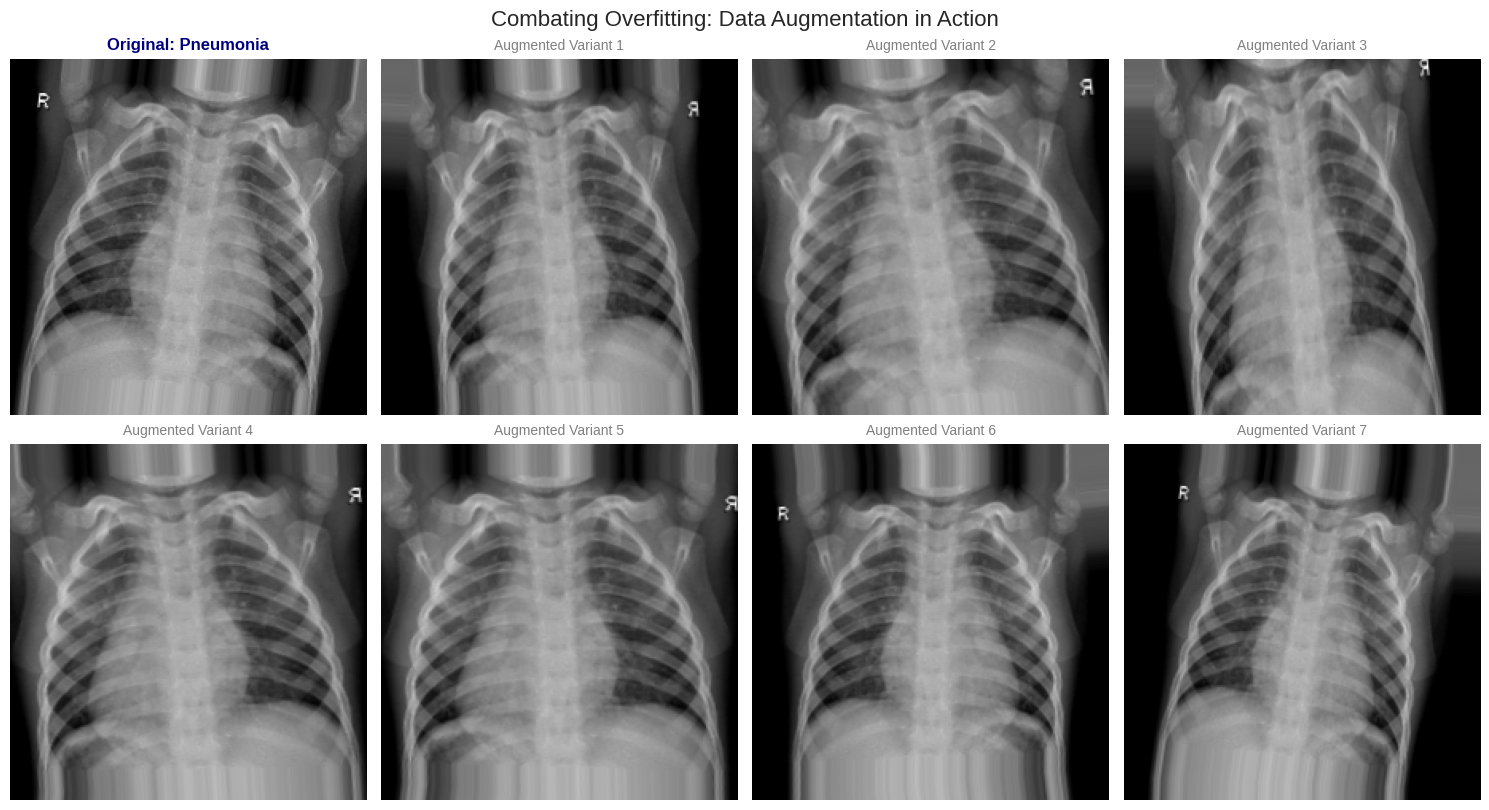

In [12]:
# 5. DATA AUGMENTATION SHOWCASE 
# We visualize how the model "sees" multiple versions of the same image 
# to prevent overfitting and improve generalization.

import numpy as np
import matplotlib.pyplot as plt

# 1. Setup a specific generator for visualization (NO rescaling here)
viz_aug_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15, 
    zoom_range=0.2, 
    horizontal_flip=True, 
    fill_mode='nearest'
)

# 2. Grab a single sample from the training data
# We take one image to show its variants
train_data.reset()
batch_images, batch_labels = next(train_data)
single_img = batch_images[0]  # Take the first image of the batch
target_label = "Pneumonia" if batch_labels[0] == 1 else "Normal"

# 3. Prepare the image for the augmentation loop
img_array = np.expand_dims(single_img, axis=0)
aug_iter = viz_aug_gen.flow(img_array, batch_size=1)

# 4. Plotting
plt.figure(figsize=(15, 8))

# Plot the Original
plt.subplot(2, 4, 1)
plt.imshow(single_img)
plt.title(f"Original: {target_label}", fontsize=12, fontweight='bold', color='navy')
plt.axis('off')

# Plot 7 Augmented Versions
for i in range(2, 9):
    plt.subplot(2, 4, i)
    aug_batch = next(aug_iter)
    plt.imshow(aug_batch[0])
    plt.title(f"Augmented Variant {i-1}", fontsize=10, color='gray')
    plt.axis('off')

plt.tight_layout()
plt.suptitle("Combating Overfitting: Data Augmentation in Action", fontsize=16, y=1.02)
plt.show()

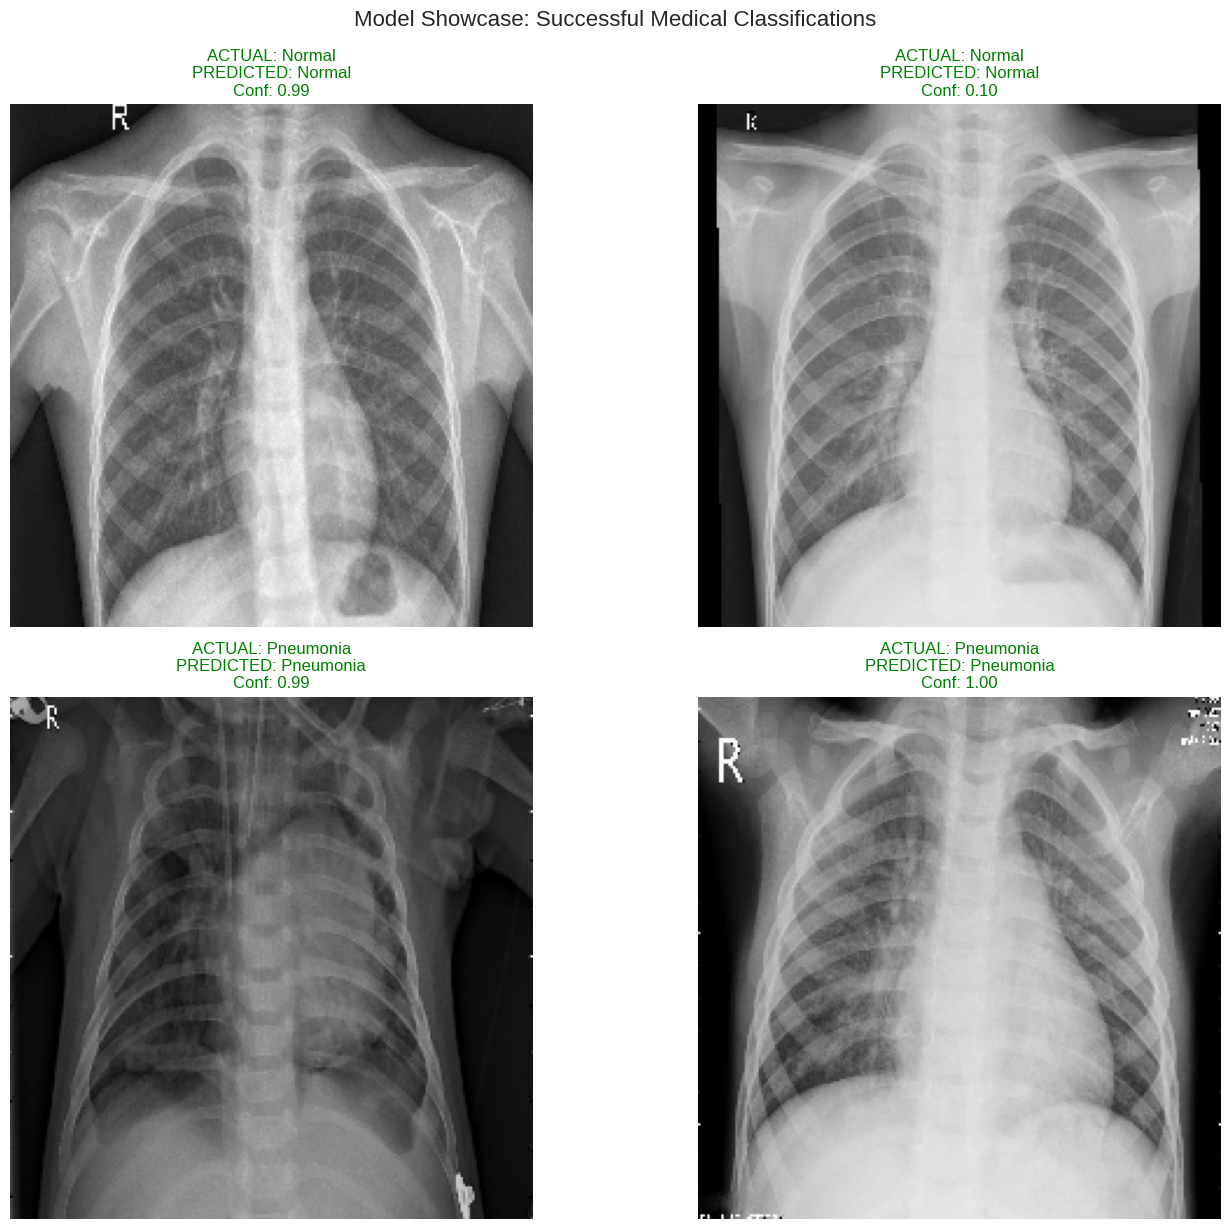

In [14]:
# 6. FINAL SHOWCASE: Visualizing correct predictions for each class
test_data.reset()
y_pred_probs = model.predict(test_data, verbose=0).ravel()
y_true = test_data.classes

# Threshold optimized earlier (using best_thresh)
y_pred = (y_pred_probs > best_thresh).astype(int)

# Separation of True Negatives (Normal correct) and True Positives (Pneumonia correct)
true_normal_indices = np.where((y_true == 0) & (y_pred == 0))[0]
true_pneumonia_indices = np.where((y_true == 1) & (y_pred == 1))[0]

# Select 2 images from each class for display
# For diversity, we grab indices that are spaced out
sel_normal = true_normal_indices[[0, len(true_normal_indices)//2]]
sel_pneumonia = true_pneumonia_indices[[0, len(true_pneumonia_indices)//2]]
sel_all = np.concatenate([sel_normal, sel_pneumonia])

plt.figure(figsize=(15, 12))
titles = ["Normal (Correct)", "Pneumonia (Correct)"]

for i, idx in enumerate(sel_all):
    plt.subplot(2, 2, i+1)
    
    # Reloading the image from test_data structure
    img, label = test_data[idx // 32] # 32 is batch_size
    img = img[idx % 32]
    
    plt.imshow(img)
    actual_label = "Pneumonia" if y_true[idx] == 1 else "Normal"
    predicted_label = "Pneumonia" if y_pred[idx] == 1 else "Normal"
    conf = y_pred_probs[idx] if y_pred[idx] == 1 else 1 - y_pred_probs[idx]
    
    # True positives/negatives get a green title
    plt.title(f"ACTUAL: {actual_label}\nPREDICTED: {predicted_label}\nConf: {conf:.2f}", color='green')
    plt.axis('off')

plt.tight_layout()
plt.suptitle("Model Showcase: Successful Medical Classifications", fontsize=16, y=1.02)
plt.show()

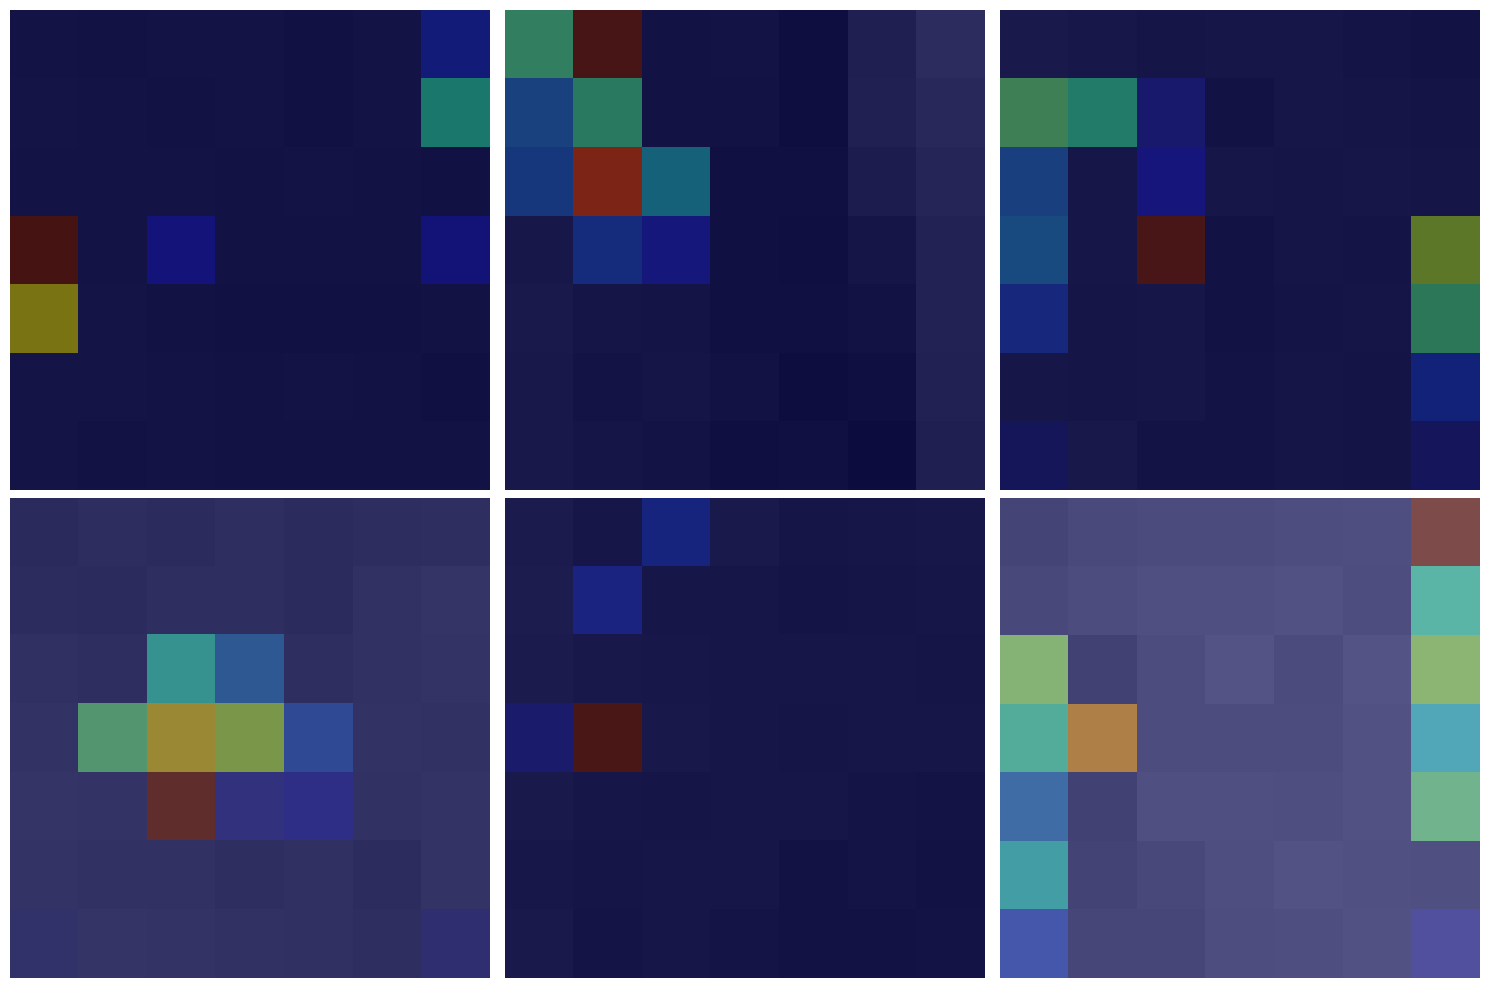

In [7]:
# 7. EXPLAINABLE AI: GRAD-CAM HEATMAPS
def make_gradcam(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model([model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_channel = preds[:, 0]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = last_conv_layer_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

plt.figure(figsize=(15, 10))
test_data.reset()
images, labels = next(test_data)
for i in range(6):
    plt.subplot(2, 3, i+1)
    img = images[i]
    heatmap = make_gradcam(np.expand_dims(img, axis=0), model, 'out_relu')
    plt.imshow(img)
    plt.imshow(heatmap, cmap='jet', alpha=0.4)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [20]:
model.save('pneumonia_model.h5')